# Spam Detection Model — TF-IDF + Logistic Regression

- **TF-IDF Vectorizer** 
- **Logistic Regression** 
- Preprocessing pipeline (lowercase, non-alpha removal, stopword filtering)
- Evaluation metrics (Precision / Recall / F1)
- Faster training, interpretable feature weights, no GPU required

In [1]:
import re
import pandas as pd
import numpy as np
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

# Reproducibility
np.random.seed(42)

STOP_WORDS = set(stopwords.words('english'))
print("Libraries loaded ")

Libraries loaded 


## 1. Load & Inspect Data

In [2]:
data = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv', encoding='latin-1')
df = data[['v1', 'v2']].copy()
df.columns = ['label', 'text']

print(df.head())
print(f"\nClass distribution:\n{df['label'].value_counts()}")
print(f"\nDataset shape: {df.shape}")

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Dataset shape: (5572, 2)


## 2. Preprocessing
- Lowercase & strip non-alpha characters
- Remove English stopwords (reduces noise, keeps meaningful spam signals like "free", "win", "prize")

In [3]:
import re
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = [
        stemmer.stem(w)
        for w in text.split()
        if w not in STOP_WORDS and len(w) > 1
    ]

    return " ".join(words)

df['text'] = df['text'].apply(clean_text)

print("Sample cleaned texts:")
print(df['text'].head())

Sample cleaned texts:
0    go jurong point crazi avail bugi great world l...
1                                  ok lar joke wif oni
2    free entri wkli comp win fa cup final tkt st m...
3                        dun say earli hor alreadi say
4                 nah think goe usf live around though
Name: text, dtype: object


## 3. Train / Test Split
Stratified split to preserve class balance — same approach as the LSTM version.

In [4]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"\nTrain spam ratio: {y_train.mean():.2%}")
print(f"Test  spam ratio: {y_test.mean():.2%}")

Train size: 4,457 | Test size: 1,115

Train spam ratio: 13.42%
Test  spam ratio: 13.36%


## 4. TF-IDF Vectorizer
Replaces the custom vocabulary + embedding lookup from the LSTM version.

**Key settings:**
- `max_features=10_000` — top 10K tokens by TF-IDF score (similar spirit to `MIN_FREQ` filtering)
- `ngram_range=(1, 2)` — unigrams + bigrams (captures "free money", "click here", etc.)
- `sublinear_tf=True` — applies log normalization to term frequencies (reduces bias from very frequent words)
- `min_df=2` — ignores terms appearing in fewer than 2 documents (mirrors `MIN_FREQ=2` in the LSTM vocab)

In [5]:
tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True,      # log-scale TF
    min_df=2                # mirrors MIN_FREQ=2 from LSTM version
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Vocabulary size : {len(tfidf.vocabulary_):,}")
print(f"Train matrix    : {X_train_tfidf.shape}")
print(f"Test  matrix    : {X_test_tfidf.shape}")

Vocabulary size : 7,062
Train matrix    : (4457, 7062)
Test  matrix    : (1115, 7062)


## 5. Model — Logistic Regression
Replaces the Bidirectional LSTM.

**Why Logistic Regression works well here:**
- TF-IDF features are already good linear separators for spam
- Highly interpretable — we can inspect the top spam/ham tokens
- Trains in milliseconds vs. minutes

**Key settings:**
- `C=10.0` — inverse regularization strength (analogous to dropout in the LSTM)
- `solver='lbfgs'` — efficient for sparse high-dimensional data
- `max_iter=1000` — ensures convergence

In [6]:
model = LogisticRegression(
    C=10.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)
print("Model trained ✅")
print(f"\nFeatures used : {model.coef_.shape[1]:,}")

Model trained ✅

Features used : 7,062


## ![](http://)6. Evaluation
Same metrics as the LSTM version — Precision, Recall, F1 for both classes.

In [7]:
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

Test Accuracy: 0.9848 (98.48%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



## 7. Inspect Top Features
A major advantage over LSTM — we can directly see which words drive spam/ham predictions.

In [8]:
feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]

TOP_N = 20

# Top spam-indicative tokens (highest positive coefficients)
top_spam_idx = coefs.argsort()[-TOP_N:][::-1]
top_ham_idx  = coefs.argsort()[:TOP_N]

print(f"{'Top Spam Tokens':^45}")
print("-" * 45)
for idx in top_spam_idx:
    print(f"  {feature_names[idx]:<30}  {coefs[idx]:+.4f}")

print()
print(f"{'Top Ham Tokens':^45}")
print("-" * 45)
for idx in top_ham_idx:
    print(f"  {feature_names[idx]:<30}  {coefs[idx]:+.4f}")

               Top Spam Tokens               
---------------------------------------------
  txt                             +9.6817
  uk                              +7.0311
  claim                           +6.8441
  mobil                           +6.4006
  repli                           +6.0771
  servic                          +5.8245
  www                             +5.7315
  com                             +5.3349
  prize                           +5.1301
  min                             +5.1071
  rington                         +5.0505
  video                           +4.8387
  award                           +4.5993
  tone                            +4.4216
  stop                            +4.3526
  free                            +4.2888
  new                             +4.2581
  tf                              +4.2490
  cost                            +4.2031
  order                           +4.1942

               Top Ham Tokens                
---------------------

## 8. Predict on New Messages

In [9]:
def predict(text, threshold=0.5):
    cleaned = clean_text(text)
    vec     = tfidf.transform([cleaned])
    prob    = model.predict_proba(vec)[0][1]   # P(spam)

    label = "🚨 SPAM" if prob > threshold else "✅ Ham"
    print(f"{label}  (confidence: {prob:.2%})  |  '{text[:60]}'")
    return prob

# Test examples (same as LSTM version for easy comparison)
predict("Win money now!!! Click here for a free prize!")
predict("Hey, are you coming to the meeting tomorrow?")
predict("Congratulations! You've been selected for a cash reward. Call now.")
predict("I'll be a bit late, save me some food please.")

🚨 SPAM  (confidence: 90.89%)  |  'Win money now!!! Click here for a free prize!'
✅ Ham  (confidence: 0.24%)  |  'Hey, are you coming to the meeting tomorrow?'
🚨 SPAM  (confidence: 73.43%)  |  'Congratulations! You've been selected for a cash reward. Cal'
✅ Ham  (confidence: 1.14%)  |  'I'll be a bit late, save me some food please.'


np.float64(0.011355566107005803)

# Adverserial attack

In [10]:
import pandas as pd

# Identify the Top Ham Tokens to use as "camouflage"
# We'll take the top 30 words that the model thinks strongly indicate 'Ham'
top_ham_words = [feature_names[idx] for idx in top_ham_idx[:30]]
camouflage_string = " ".join(top_ham_words)

print(f"Camouflage tokens being added: {top_ham_words}\n")

# Create the Adversarial Test Set
# We only target the Spam messages (label 1) in the test set
X_test_adv = X_test.copy()
y_test_adv = y_test.copy()

# Identify indices of spam messages in the test set
spam_indices = y_test[y_test == 1].index

# Apply the attack: Append ham words to every spam message in the test set
X_test_adv.loc[spam_indices] = X_test_adv.loc[spam_indices] + " " + camouflage_string

# Vectorize the Adversarial Test Set
X_test_adv_tfidf = tfidf.transform(X_test_adv)

# Evaluate the Model on Clean vs Adversarial Data
y_pred_clean = model.predict(X_test_tfidf)
y_pred_adv = model.predict(X_test_adv_tfidf)

print("="*50)
print("PERFORMANCE ON CLEAN TEST DATA")
print("="*50)
print(classification_report(y_test, y_pred_clean, target_names=['Ham', 'Spam']))

print("\n" + "="*50)
print("PERFORMANCE ON ADVERSARIAL TEST DATA (Evasion Attack)")
print("="*50)
print(classification_report(y_test_adv, y_pred_adv, target_names=['Ham', 'Spam']))

# Visualizing a few specific failures
print("\nExamples of successfully evaded Spam:")
print("-" * 30)

# Find samples that were Spam (1) but predicted as Ham (0) after the attack
evaded_mask = (y_test == 1) & (y_pred_adv == 0)
evaded_indices = X_test_adv[evaded_mask].index[:3]

for idx in evaded_indices:
    # Original clean text (from the dataframe before cleaning if possible, or just the cleaned version)
    original = X_test.loc[idx]
    
    # Get probability from the model
    vec = tfidf.transform([X_test_adv.loc[idx]])
    prob = model.predict_proba(vec)[0][1]
    
    print(f"Original: {original}")
    print(f"Adversarial Prob(Spam): {prob:.2%}")
    print(f"Final Prediction: ✅ Ham (Attack Successful)")
    print("-" * 10)

Camouflage tokens being added: ['home', 'ok', 'gt', 'lt', 'sorri', 'lt gt', 'later', 'got', 'say', 'yup', 'mail', 'way', 'hey', 'lor', 'sir', 'da', 'morn', 'wat', 'happi', 'lol']

PERFORMANCE ON CLEAN TEST DATA
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115


PERFORMANCE ON ADVERSARIAL TEST DATA (Evasion Attack)
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       966
        Spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115


Examples of successfully evaded Spam:
------------------------------
Original: 

In [11]:
print(" Adversarial Attack (Evasion) ")

# Identify the strongest 'Ham' words from your existing model
top_ham_words = [feature_names[idx] for idx in top_ham_idx[:15]]
print(f"Adding these ham words to trick the model: {top_ham_words}\n")

# Define a spam message
original_spam = "WINNER! You have won a cash prize of £1000. Call 09012345678 to claim now!"

# Create the adversarial version
# We append ham words that usually appear in 'ham' messages (like 'gt', 'lt', 'lor', 'ok')
adversarial_spam = original_spam + " " + " ".join(top_ham_words)

print("Original Prediction:")
predict(original_spam)

print("\nAdversarial Prediction (Same message + Ham words):")
predict(adversarial_spam)

 Adversarial Attack (Evasion) 
Adding these ham words to trick the model: ['home', 'ok', 'gt', 'lt', 'sorri', 'lt gt', 'later', 'got', 'say', 'yup', 'mail', 'way', 'hey', 'lor', 'sir']

Original Prediction:
🚨 SPAM  (confidence: 97.84%)  |  'WINNER! You have won a cash prize of £1000. Call 09012345678'

Adversarial Prediction (Same message + Ham words):
✅ Ham  (confidence: 0.21%)  |  'WINNER! You have won a cash prize of £1000. Call 09012345678'


np.float64(0.00208990527818018)

# Poisoning Attack

first we try to get the best poison rate for the attack to be stealthy

Poison 5%  |  Accuracy: 0.9740  |  Spam Recall: 0.8054  |  Missed Spam: 29
Poison 10%  |  Accuracy: 0.9453  |  Spam Recall: 0.5906  |  Missed Spam: 60
Poison 15%  |  Accuracy: 0.9130  |  Spam Recall: 0.3490  |  Missed Spam: 97
Poison 20%  |  Accuracy: 0.9130  |  Spam Recall: 0.3490  |  Missed Spam: 97

🔴 Worst stealthy rate: 15%
   Accuracy  : 0.9130  ← looks fine
   Spam Recall: 0.3490  ← quietly failing
   Missed Spam: 97 messages slipping through


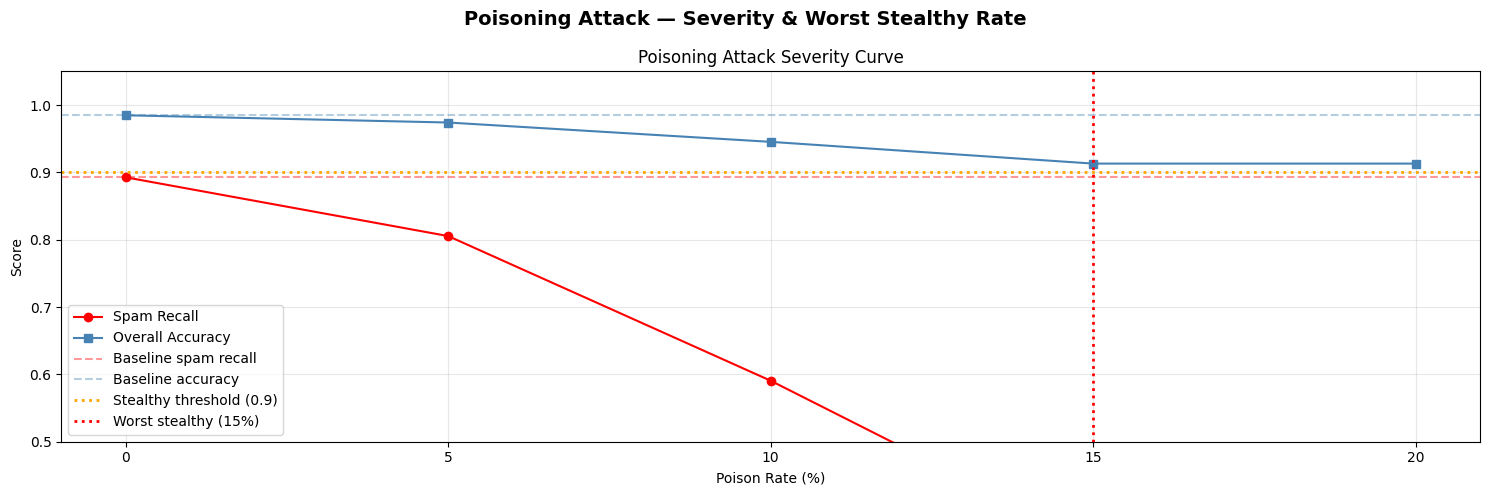


Poison Rate       Accuracy   Spam Recall   Missed Spam
0% (clean)          0.9848        0.8926             0
5%                  0.9740        0.8054            29
10%                  0.9453        0.5906            60
15%                  0.9130        0.3490            97 ← worst and stealthy
20%                  0.9130        0.3490            97


In [12]:
# POISONING ATTACK — SEVERITY CURVE + WORST STEALTHY RATE

from sklearn.metrics import recall_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
POISON_RATES = [0.05, 0.10, 0.15, 0.20]
results = []

for rate in POISON_RATES:
    spam_samples = X_train[y_train == 1]
    n_poison = min(int(len(X_train) * rate), len(spam_samples))

    X_poison  = spam_samples.sample(n=n_poison, random_state=42)
    y_poison  = pd.Series([0] * n_poison, index=X_poison.index)

    X_train_p = pd.concat([X_train, X_poison]).reset_index(drop=True)
    y_train_p = pd.concat([y_train, y_poison]).reset_index(drop=True)
    X_train_p, y_train_p = shuffle(X_train_p, y_train_p, random_state=42)

    p_tfidf    = TfidfVectorizer(max_features=10_000, ngram_range=(1,2), sublinear_tf=True, min_df=2)
    X_tr_tfidf = p_tfidf.fit_transform(X_train_p)
    X_te_tfidf = p_tfidf.transform(X_test)

    p_model = LogisticRegression(C=10.0, max_iter=1000, random_state=42)
    p_model.fit(X_tr_tfidf, y_train_p)

    y_pred_p    = p_model.predict(X_te_tfidf)
    acc         = accuracy_score(y_test, y_pred_p)
    spam_recall = recall_score(y_test, y_pred_p)
    missed_spam = int((y_test == 1).sum() * (1 - spam_recall))

    results.append({
        'rate': rate, 'accuracy': acc,
        'spam_recall': spam_recall,
        'missed_spam': missed_spam,
        'y_pred': y_pred_p
    })

    if rate == 0.15:
        saved_model  = p_model
        saved_tfidf  = p_tfidf

    print(f"Poison {rate*100:.0f}%  |  Accuracy: {acc:.4f}  |  Spam Recall: {spam_recall:.4f}  |  Missed Spam: {missed_spam}")

# Baseline
base_recall = recall_score(y_test, model.predict(X_test_tfidf))
base_acc    = accuracy_score(y_test, model.predict(X_test_tfidf))

# "Stealthy" = accuracy stays above 0.95 (looks normal to anyone monitoring)
# "Worst"    = lowest spam recall among those stealthy ones (most damage done quietly)

STEALTHY_THRESHOLD = 0.90
stealthy = [r for r in results if r['accuracy'] >= STEALTHY_THRESHOLD]
worst_stealthy = min(stealthy, key=lambda x: x['spam_recall']) if stealthy else min(results, key=lambda x: x['spam_recall'])

print(f"\n🔴 Worst stealthy rate: {int(worst_stealthy['rate']*100)}%")
print(f"   Accuracy  : {worst_stealthy['accuracy']:.4f}  ← looks fine")
print(f"   Spam Recall: {worst_stealthy['spam_recall']:.4f}  ← quietly failing")
print(f"   Missed Spam: {worst_stealthy['missed_spam']} messages slipping through")

# Plot: Severity Curve 
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes = [axes]
# Left: Severity Curve
rates        = [0]          + [r['rate']        for r in results]
spam_recalls = [base_recall] + [r['spam_recall'] for r in results]
accuracies   = [base_acc] + [r['accuracy'] for r in results]

axes[0].plot([r*100 for r in rates], spam_recalls, marker='o', color='red',       label='Spam Recall')
axes[0].plot([r*100 for r in rates], accuracies,   marker='s', color='steelblue', label='Overall Accuracy')
axes[0].axhline(y=base_recall, color='red',       linestyle='--', alpha=0.4, label='Baseline spam recall')
axes[0].axhline(y=base_acc,    color='steelblue', linestyle='--', alpha=0.4, label='Baseline accuracy')
axes[0].axhline(y=STEALTHY_THRESHOLD, color='orange', linestyle=':', linewidth=2, label=f'Stealthy threshold ({STEALTHY_THRESHOLD})')
axes[0].axvline(x=worst_stealthy['rate']*100, color='red', linestyle=':', linewidth=2,
                label=f"Worst stealthy ({int(worst_stealthy['rate']*100)}%)")

axes[0].set_xlabel('Poison Rate (%)')
axes[0].set_ylabel('Score')
axes[0].set_title('Poisoning Attack Severity Curve')
axes[0].set_xticks([0, 5, 10, 15, 20])
axes[0].set_ylim(0.5, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)


plt.suptitle('Poisoning Attack — Severity & Worst Stealthy Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table 
print("\n" + "="*65)
print(f"{'Poison Rate':<15} {'Accuracy':>10} {'Spam Recall':>13} {'Missed Spam':>13}")
print("="*65)
print(f"{'0% (clean)':<15} {base_acc:>10.4f} {base_recall:>13.4f} {'0':>13}")
for r in results:
    marker = " ← worst and stealthy" if r['rate'] == worst_stealthy['rate'] else ""
    print(f"{r['rate']*100:.0f}%{'':<13} {r['accuracy']:>10.4f} {r['spam_recall']:>13.4f} {r['missed_spam']:>13}{marker}")
print("="*65)

Then we get the confustion matrix of it

In [13]:
rate_15 = next(r for r in results if r['rate'] == 0.15)

print("\n" + "="*50)
print("RESULTS AFTER POISONING (15.0% rate)")
print("="*50)
print(classification_report(y_test, rate_15['y_pred'], target_names=['Ham', 'Spam']))

print("\nWeight Check for 'FREE':")
try:
    p_feature_names = saved_tfidf.get_feature_names_out()
    p_coefs         = saved_model.coef_[0]
    idx = list(p_feature_names).index('free')
    print(f"The word 'free' now has weight: {p_coefs[idx]:.4f} (In clean model, it was very positive)")
except:
    print("'free' not in vocabulary")


RESULTS AFTER POISONING (15.0% rate)
              precision    recall  f1-score   support

         Ham       0.91      1.00      0.95       966
        Spam       1.00      0.35      0.52       149

    accuracy                           0.91      1115
   macro avg       0.95      0.67      0.73      1115
weighted avg       0.92      0.91      0.89      1115


Weight Check for 'FREE':
The word 'free' now has weight: 2.9791 (In clean model, it was very positive)


# DEFENSE 1: Adversarial Training

In [14]:
# DEFENSE 1 — Adversarial Training

# Create adversarial version of TRAIN data (same attack as test)
X_train_adv = X_train.copy()

spam_indices_train = y_train[y_train == 1].index
X_train_adv.loc[spam_indices_train] = (
    X_train_adv.loc[spam_indices_train] + " " + camouflage_string
)

# Combine clean + adversarial data
X_train_def = pd.concat([X_train, X_train_adv])
y_train_def = pd.concat([y_train, y_train])

print(f"Original train size: {len(X_train)}")
print(f"After defense train size: {len(X_train_def)}")

Original train size: 4457
After defense train size: 8914


In [15]:
# Vectorize again
tfidf_def = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_def_tfidf = tfidf_def.fit_transform(X_train_def)
X_test_def_tfidf  = tfidf_def.transform(X_test_adv)  # evaluate on attacked test

# Train new model
model_def = LogisticRegression(
    C=10.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model_def.fit(X_train_def_tfidf, y_train_def)

print("Defended model trained!")

Defended model trained!


In [16]:
# Predictions
y_pred_def1 = model_def.predict(X_test_def_tfidf)

acc_def1 = accuracy_score(y_test, y_pred_def1)

print("="*50)
print("DEFENSE 1 — Adversarial Training Results")
print("="*50)
print(f"Accuracy after defense: {acc_def1:.4f}\n")

print(classification_report(y_test, y_pred_def1, target_names=['Ham', 'Spam']))

DEFENSE 1 — Adversarial Training Results
Accuracy after defense: 0.9991

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       966
        Spam       0.99      1.00      1.00       149

    accuracy                           1.00      1115
   macro avg       1.00      1.00      1.00      1115
weighted avg       1.00      1.00      1.00      1115



# DEFENSE 2: Input Sanitization

In [17]:
# DEFENSE 2 — Input Sanitization

# We'll remove excessive repetition of top ham words
top_ham_set = set(top_ham_words)

def sanitize_text(text):
    words = text.split()

    # Keep only first occurrence of suspicious ham tokens
    seen = set()
    filtered_words = []

    for w in words:
        if w in top_ham_set:
            if w not in seen:
                filtered_words.append(w)
                seen.add(w)
        else:
            filtered_words.append(w)

    return " ".join(filtered_words)

# Apply sanitization to adversarial test set
X_test_sanitized = X_test_adv.apply(sanitize_text)

In [18]:
# Transform using ORIGINAL tfidf (important!)
X_test_sanitized_tfidf = tfidf.transform(X_test_sanitized)

y_pred_def2 = model.predict(X_test_sanitized_tfidf)

acc_def2 = accuracy_score(y_test, y_pred_def2)

print("="*50)
print("DEFENSE 2 — Input Sanitization Results")
print("="*50)
print(f"Accuracy after defense: {acc_def2:.4f}\n")

print(classification_report(y_test, y_pred_def2, target_names=['Ham', 'Spam']))

DEFENSE 2 — Input Sanitization Results
Accuracy after defense: 0.8664

              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       966
        Spam       0.50      0.01      0.01       149

    accuracy                           0.87      1115
   macro avg       0.68      0.50      0.47      1115
weighted avg       0.82      0.87      0.81      1115




📊 MODEL PERFORMANCE COMPARISON
                          Accuracy  Precision  Recall  F1 Score
Before Attack               0.9848     0.9925  0.8926    0.9399
After Attack                0.8655     0.0000  0.0000    0.0000
Defense 1 (Adv Training)    0.9991     0.9933  1.0000    0.9967
Defense 2 (Sanitization)    0.8664     0.5000  0.0067    0.0132

🏆 Best per metric:
Accuracy     Defense 1 (Adv Training)
Precision    Defense 1 (Adv Training)
Recall       Defense 1 (Adv Training)
F1 Score     Defense 1 (Adv Training)
dtype: object


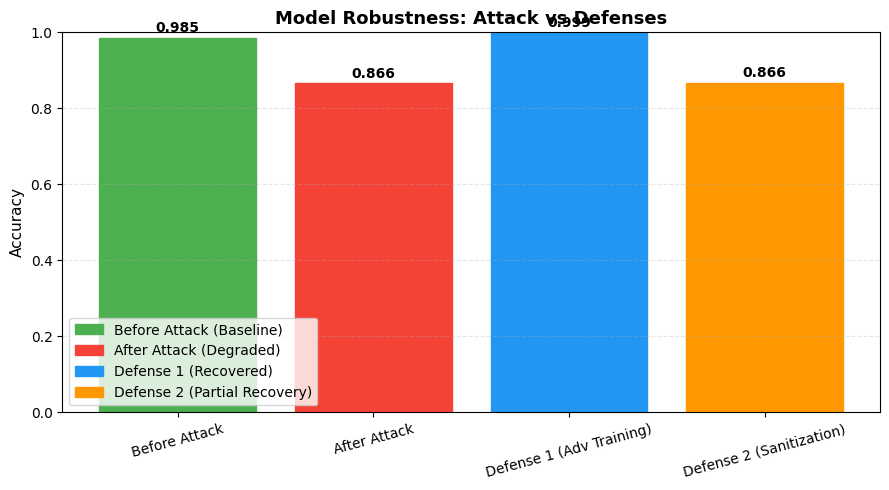

In [19]:
# FINAL COMPARISON — CLEAN + PROFESSIONAL VERSION

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------
# Metrics function
# -------------------------
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

# -------------------------
# Collect metrics
# -------------------------
results = {
    "Before Attack": get_metrics(y_test, y_pred_clean),
    "After Attack": get_metrics(y_test, y_pred_adv),
    "Defense 1 (Adv Training)": get_metrics(y_test, y_pred_def1),
    "Defense 2 (Sanitization)": get_metrics(y_test, y_pred_def2),
}

comparison_df = pd.DataFrame(results).T

# Round for clean display
comparison_df = comparison_df.round(4)

# -------------------------
# Print nicely formatted table
# -------------------------
print("\n" + "="*75)
print("📊 MODEL PERFORMANCE COMPARISON")
print("="*75)
print(comparison_df)

# Highlight best values (optional nice touch)
print("\n🏆 Best per metric:")
print(comparison_df.idxmax())

# -------------------------
# Accuracy Plot (Improved)
# -------------------------
scenarios = comparison_df.index
accuracies = comparison_df["Accuracy"].values

plt.figure(figsize=(9,5))

bars = plt.bar(scenarios, accuracies)

# Color styling (highlight phases)
colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.ylabel("Accuracy", fontsize=11)
plt.title("Model Robustness: Attack vs Defenses", fontsize=13, fontweight='bold')
plt.ylim(0, 1)

# Annotate bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.015, f"{v:.3f}", ha='center', fontsize=10, fontweight='bold')

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add legend manually
import matplotlib.patches as mpatches
legend_labels = [
    "Before Attack (Baseline)",
    "After Attack (Degraded)",
    "Defense 1 (Recovered)",
    "Defense 2 (Partial Recovery)"
]
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, legend_labels)]
plt.legend(handles=patches, loc='lower left')

plt.tight_layout()
plt.show()